# Fake News Detection Using Natural Language Processing

## 1. Project Objective

The objective of this project is to develop a binary text classification model for distinguishing between true and fake news articles using natural language processing and machine learning techniques.

The performance of Logistic Regression, Multinomial Naive Bayes, and Linear Support Vector Machine (SVM) classifiers is compared using TF-IDF and n-gram-based text representations.

loading the dataset

In [ ]:
import pandas as pd

true_df = pd.read_csv("true.csv")
fake_df = pd.read_csv("fake.csv")

checking the data

In [20]:
print(true_df.shape)
print(fake_df.shape)

print(true_df.columns)
print(fake_df.columns)

(21417, 4)
(23481, 4)
Index(['title', 'text', 'subject', 'date'], dtype='object')
Index(['title', 'text', 'subject', 'date'], dtype='object')


labelling true news as '0' and fake as '1' and mixing the 2 datasets in a random shuffle

In [21]:
true_df["label"] = 0
fake_df["label"] = 1

df = pd.concat([true_df, fake_df], ignore_index=True)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
print(df.shape)
print(df["label"].value_counts())
df.isnull().sum() #checking for presence of NA

(44898, 5)
label
1    23481
0    21417
Name: count, dtype: int64


title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [26]:
print(df[["title", "text", "subject", "date", "label"]].head())
print(df["subject"].value_counts())
print(df["date"].head())

##checking for duplicate entries
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate titles:", df["title"].duplicated().sum())
print("Duplicate texts:", df["text"].duplicated().sum())

                                               title  \
0   BREAKING: GOP Chairman Grassley Has Had Enoug...   
1   Failed GOP Candidates Remembered In Hilarious...   
2   Mike Pence’s New DC Neighbors Are HILARIOUSLY...   
3  California AG pledges to defend birth control ...   
4  AZ RANCHERS Living On US-Mexico Border Destroy...   

                                                text       subject  \
0  Donald Trump s White House is in chaos, and th...          News   
1  Now that Donald Trump is the presumptive GOP n...          News   
2  Mike Pence is a huge homophobe. He supports ex...          News   
3  SAN FRANCISCO (Reuters) - California Attorney ...  politicsNews   
4  Twisted reasoning is all that comes from Pelos...      politics   

               date  label  
0     July 21, 2017      1  
1       May 7, 2016      1  
2  December 3, 2016      1  
3  October 6, 2017       0  
4      Apr 25, 2017      1  
subject
politicsNews       11272
worldnews          10145
News      

removing duplicate rows but not rows with duplicate titles since those might be reports of same incidents reported by different news sources

In [ ]:
df = df.drop_duplicates(subset="text").copy()
print(df.shape)
print(df["label"].value_counts())
print(df["text"].duplicated().sum())

(38646, 5)
label
0    21191
1    17455
Name: count, dtype: int64
(38646, 5)
label
0    21191
1    17455
Name: count, dtype: int64
0


Question of interest: Given the title + article text, is this article True or Fake?

We split the data in train/test subsets first in 80/20 percentages

In [29]:
df["article"] = df["title"] + " " + df["text"]
X = df["article"]
y = df["label"]

#train_test split (4:1)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(30916,)
(7730,)
label
0    16952
1    13964
Name: count, dtype: int64
label
0    4239
1    3491
Name: count, dtype: int64


TF-IDF matrix

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000, #we limit the vocabulary to 5e3 most useful features to prevent getting a large sparse high-dimensional matrix
    ngram_range=(1, 2) #considering unigrams and bigrams
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

print(type(X_train_tfidf)) #not our regular NumPy matrix 

(30916, 5000)
(7730, 5000)
<class 'scipy.sparse._csr.csr_matrix'>


Model 1: Using logistic regression for classification and predicition

Accuracy: 0.988745148771022

              precision    recall  f1-score   support

        True       0.99      0.99      0.99      4239
        Fake       0.99      0.98      0.99      3491

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730

Logistic Regression Accuracy: 0.9887


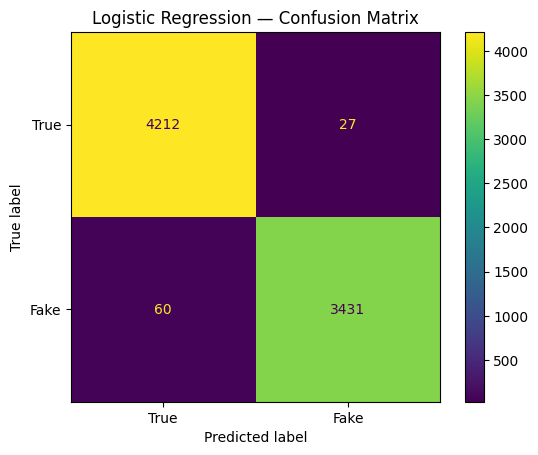

[[4212   27]
 [  60 3431]]


In [33]:
#fitting the model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_tfidf, y_train)

#predictions based on test data
pred_lr = lr.predict(X_test_tfidf)

#accuracy metrics
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, pred_lr))
print()
print(classification_report(
    y_test,
    pred_lr,
    target_names=["True", "Fake"]
))

lr_accuracy = accuracy_score(y_test, pred_lr)

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

#confusion matrix, sensitivity and specificity or equivalently TPR, FPR of the model

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_lr = confusion_matrix(y_test, pred_lr)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["True", "Fake"]
).plot()

import matplotlib.pyplot as plt
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

print(cm_lr)

Model 2: Multinomial Naive Bayes Classification

CountVectorizer to evaluate word-count features

In [34]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

count_vec = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_count = count_vec.fit_transform(X_train)
X_test_count = count_vec.transform(X_test)

nb = MultinomialNB()

nb.fit(X_train_count, y_train)

pred_nb = nb.predict(X_test_count)

from sklearn.metrics import accuracy_score, classification_report

print("Naive Bayes Accuracy:", accuracy_score(y_test, pred_nb))
print()

print(classification_report(
    y_test,
    pred_nb,
    target_names=["True", "Fake"]
))

Naive Bayes Accuracy: 0.963130659767141

              precision    recall  f1-score   support

        True       0.96      0.97      0.97      4239
        Fake       0.96      0.95      0.96      3491

    accuracy                           0.96      7730
   macro avg       0.96      0.96      0.96      7730
weighted avg       0.96      0.96      0.96      7730



Logistic Regression outperformed Multinomial Naive Bayes, suggesting that the discriminative linear model was better suited to the TF-IDF representation for this dataset.

Model 3: SVM classification (Linear SVM)

SVM Accuracy: 0.9941785252263907

              precision    recall  f1-score   support

        True       0.99      1.00      0.99      4239
        Fake       0.99      0.99      0.99      3491

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730

[[4219   20]
 [  25 3466]]


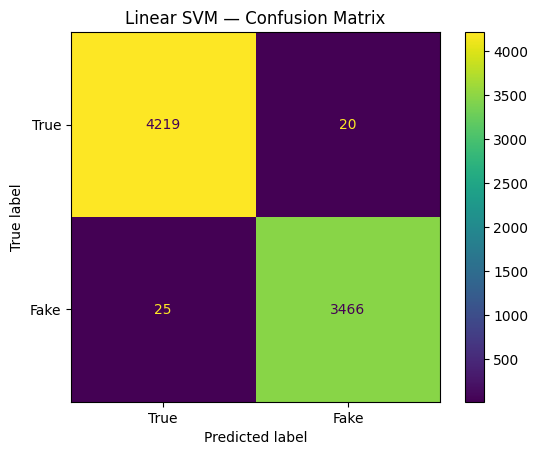

Accuracy : 0.9941785252263907
Precision: 0.9942627653471027
Recall   : 0.9928387281581209
F1 Score : 0.9935502364913287


In [37]:
#using the same tf-idf matrices we had obtained during logistic regression fitting
X_train_tfidf
X_test_tfidf

#fitting the model
from sklearn.svm import LinearSVC

svm = LinearSVC(
    C=1.0,
    max_iter=5000
)

svm.fit(X_train_tfidf, y_train)

#predictions
pred_svm = svm.predict(X_test_tfidf)

#accuracy measure
print("SVM Accuracy:", accuracy_score(y_test, pred_svm))
print()

print(classification_report(
    y_test,
    pred_svm,
    target_names=["True", "Fake"]
))

#confusion matrix
cm_svm = confusion_matrix(y_test, pred_svm)

print(cm_svm)

ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["True", "Fake"]
).plot()

plt.title("Linear SVM — Confusion Matrix")
plt.show()

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, pred_svm))
print("Precision:", precision_score(y_test, pred_svm))
print("Recall   :", recall_score(y_test, pred_svm))
print("F1 Score :", f1_score(y_test, pred_svm))

comparison table among the performances of each model

In [38]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_nb),
        accuracy_score(y_test, pred_svm)
    ],
    "Precision": [
        precision_score(y_test, pred_lr),
        precision_score(y_test, pred_nb),
        precision_score(y_test, pred_svm)
    ],
    "Recall": [
        recall_score(y_test, pred_lr),
        recall_score(y_test, pred_nb),
        recall_score(y_test, pred_svm)
    ],
    "F1 Score": [
        f1_score(y_test, pred_lr),
        f1_score(y_test, pred_nb),
        f1_score(y_test, pred_svm)
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9887,0.9922,0.9828,0.9875
1,Naive Bayes,0.9631,0.9636,0.9545,0.9590
2,Linear SVM,0.9942,0.9943,0.9928,0.9936


Interpretation of results obtained using SVM i.e the best-performing model out of the 3

In [41]:
import numpy as np

feature_names = np.array(tfidf.get_feature_names_out())

coefficients = svm.coef_[0]

fake_features = np.argsort(coefficients)[-20:][::-1]
true_features = np.argsort(coefficients)[:20]

print("Top features associated with FAKE news:")
for i in fake_features:
    print(feature_names[i], round(coefficients[i], 3))

print("\nTop features associated with TRUE news:")
for i in true_features:
    print(feature_names[i], round(coefficients[i], 3))

Top features associated with FAKE news:
via 7.017
read more 4.385
video 3.427
president trump 3.138
breaking 2.708
gop 2.487
featured image 2.399
just 2.367
mr 2.325
hillary 2.276
read 2.263
the us 2.25
image 2.235
featured 2.224
this 2.218
watch 2.193
getty 2.025
rep 1.954
getty images 1.916
image via 1.913

Top features associated with TRUE news:
reuters -13.754
washington reuters -5.017
said -4.709
reuters the -3.236
president donald -2.458
on tuesday -2.44
reuters president -2.368
on wednesday -2.346
on -2.318
on friday -2.247
said on -2.227
on thursday -2.14
york reuters -1.94
bit -1.935
on monday -1.826
republican -1.798
some -1.646
nov -1.605
washington -1.592
showed -1.555


Feature analysis revealed that the Linear SVM relied heavily on source- and formatting-related lexical patterns. Terms such as "Reuters" were strongly associated with the True class, while phrases such as "read more", "featured image", and "Getty Images" were associated with the Fake class. This indicates that the classifier may exploit dataset-specific stylistic and source cues in addition to linguistic content. Consequently, the high test-set performance may not directly translate to unseen real-world news sources.